# Bank churn — merged pipeline

## Business context

Banks lose revenue when customers **churn**; keeping an existing customer is usually cheaper than acquiring a new one. This notebook supports **early identification** of customers likely to leave so the bank can target retention (offers, service changes, etc.).

**Goal:** predict **who will leave** (binary churn).

**Outcomes:** (1) a churn score / class, (2) **evaluation** on held-out data, and (3) **insight** into which customer attributes align with higher churn risk.

## Modeling approach

1. **Logistic regression** — interpretable **coefficients** for linear risk structure.
2. **Neural network (MLP)** — **nonlinear** patterns on scaled inputs.
3. **Decision tree** — a single **if–then** structure and split importances (hyperparameters tuned with grid search).
4. **Random forest** — an **ensemble** of trees; typically lower variance than one tree, with aggregated feature importance.
5. **KNN** — **similarity** on scaled features; number of neighbors *k* selected by cross-validation on the training set.

Flow: **linear baseline → nonlinear model → tree (interpretable) → forest (ensemble) → instance-based comparison.**

## This notebook

End-to-end workflow: preparation, exploratory views, one stratified train/test split, then the models listed above.

**Data:** `BankChurners.csv` — drop the ID column and `Naive_Bayes_*` leakage columns, encode the target, one-hot encode categoricals, and use `StandardScaler` for logistic regression, MLP, and KNN. **Decision tree and random forest** use **unscaled** `X_train` / `X_test` so thresholds and splits stay in original feature units.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
)


## Load and clean

- Drop `CLIENTNUM` (identifier).
- Drop `Naive_Bayes_Classifier...` columns (leakage from another model).
- Target: `Existing Customer` = 0, `Attrited Customer` = 1.


In [2]:
df = pd.read_csv("BankChurners.csv")

drop_cols = ["CLIENTNUM"] + [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]
df = df.drop(columns=drop_cols)

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
})

df.head()


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Exploratory plots

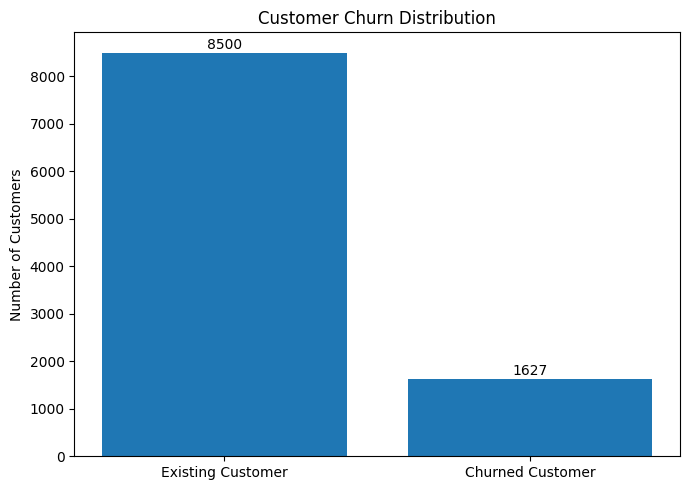

Churn rate: 16.07%


In [3]:
churn_counts = df["Attrition_Flag"].value_counts().sort_index()
labels = ["Existing Customer", "Churned Customer"]

plt.figure(figsize=(7, 5))
plt.bar(labels, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 80, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Attrition_Flag'].mean() * 100:.2f}%")


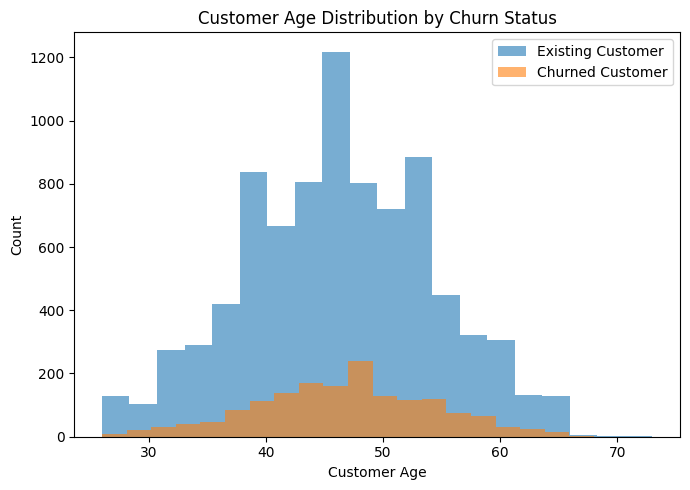

In [4]:
plt.figure(figsize=(7, 5))
for target_value, label in [(0, "Existing Customer"), (1, "Churned Customer")]:
    plt.hist(
        df.loc[df["Attrition_Flag"] == target_value, "Customer_Age"],
        bins=20,
        alpha=0.6,
        label=label,
    )
plt.title("Customer Age Distribution by Churn Status")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


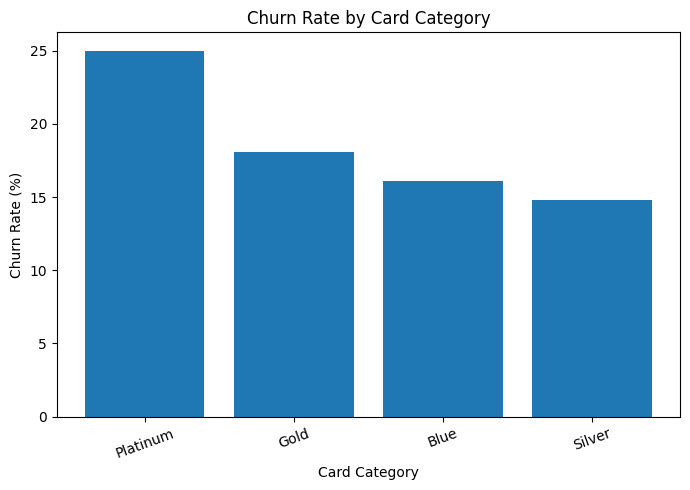

,Churn Rate (%)
Card_Category,
Platinum,25.000000
Gold,18.103448
Blue,16.097923
Silver,14.774775


In [5]:
card_churn = (
    df.groupby("Card_Category")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(7, 5))
plt.bar(card_churn.index, card_churn.values)
plt.title("Churn Rate by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

card_churn.to_frame(name="Churn Rate (%)")


## Transaction Count vs. Churn Customer
Compare the total transaction count of existing customers and churned customers

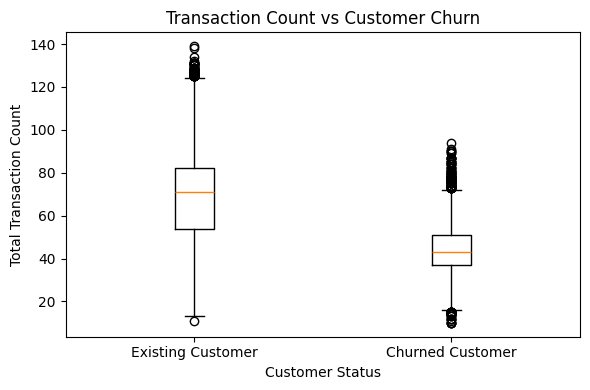

In [6]:
# Separate transaction counts by customer status
existing = df[df["Attrition_Flag"] == 0]["Total_Trans_Ct"]
churned = df[df["Attrition_Flag"] == 1]["Total_Trans_Ct"]

plt.figure(figsize=(6, 4))

# Boxplot to compare distribution between the two groupd
plt.boxplot([existing, churned], labels=["Existing Customer", "Churned Customer"])

plt.title("Transaction Count vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Total Transaction Count")

plt.tight_layout()
plt.show()

## Train / test split and scaling

Categorical columns are one-hot encoded (`drop_first=True`). Train/test split: 80/20, `random_state=42`, stratified on `y`.

**Scaled** matrices are used for logistic regression, MLP, and KNN. **Decision tree and random forest** are fit on **unscaled** `X_train` / evaluated on `X_test` so splits and importances stay in original feature units.


In [7]:
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Feature matrix shape: (10127, 32)


## 1. Logistic Regression

- Confusion matrix (counts + normalized)
- Top coefficients with odds ratios
- ROC curve
- 5-fold CV F1 on training data


In [8]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

log_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_log, zero_division=0),
    "AUC": roc_auc_score(y_test, y_prob_log),
}
pd.DataFrame(log_metrics, index=["Logistic Regression"]).T


,Logistic Regression
Accuracy,0.854886
Precision,0.530938
Recall,0.818462
F1 Score,0.644068
AUC,0.920669


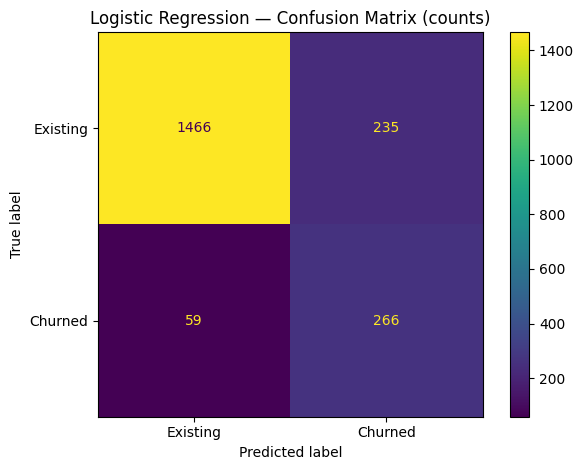

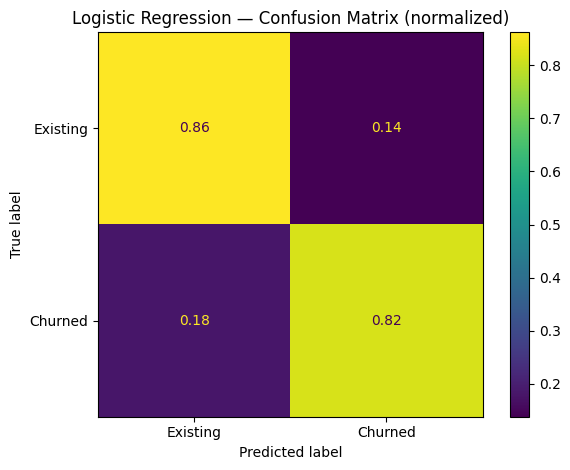

In [9]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Existing", "Churned"])
disp.plot()
plt.title("Logistic Regression — Confusion Matrix (counts)")
plt.tight_layout()
plt.show()

disp_norm = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, display_labels=["Existing", "Churned"], normalize="true"
)
disp_norm.ax_.set_title("Logistic Regression — Confusion Matrix (normalized)")
plt.tight_layout()
plt.show()


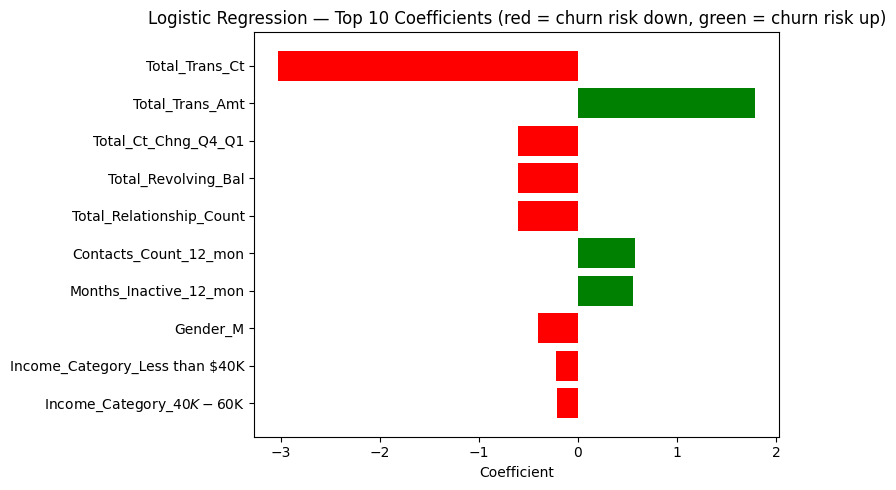

,Feature,Coefficient,Odds_Ratio
11,Total_Trans_Ct,-3.024478,0.048583
10,Total_Trans_Amt,1.790733,5.993846
12,Total_Ct_Chng_Q4_Q1,-0.606237,0.545400
7,Total_Revolving_Bal,-0.604718,0.546228
3,Total_Relationship_Count,-0.601669,0.547896
5,Contacts_Count_12_mon,0.579679,1.785465
4,Months_Inactive_12_mon,0.557786,1.746801
14,Gender_M,-0.402141,0.668887
27,Income_Category_Less than $40K,-0.226488,0.797329
24,Income_Category_$40K - $60K,-0.214332,0.807080


In [10]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": log_model.coef_[0]})
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
top10_coef = coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

colors = ["red" if c < 0 else "green" for c in top10_coef["Coefficient"][::-1]]
plt.figure(figsize=(8, 5))
plt.barh(top10_coef["Feature"][::-1], top10_coef["Coefficient"][::-1], color=colors)
plt.title("Logistic Regression — Top 10 Coefficients (red = churn risk down, green = churn risk up)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

top10_coef[["Feature", "Coefficient", "Odds_Ratio"]]


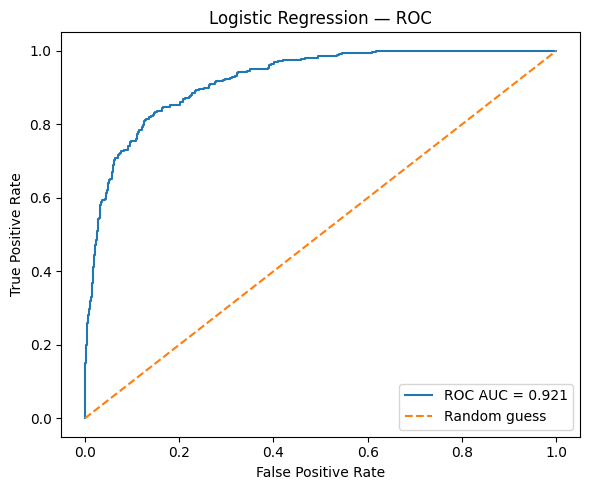

In [11]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"ROC AUC = {auc_log:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.title("Logistic Regression — ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
lr_cv_f1 = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring="f1")
print("5-fold CV F1 (train):", lr_cv_f1)
print("Mean:", lr_cv_f1.mean())


5-fold CV F1 (train): [0.62017804 0.65248227 0.64411765 0.63519313 0.64919942]
Mean: 0.6402341017821953


## 2. Neural Network (MLP)

Small two-hidden-layer MLP on scaled inputs. `sample_weight` uses the balanced scheme to reflect class imbalance (MLP has no `class_weight` argument).


In [13]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
sample_w = compute_sample_weight("balanced", y_train)
mlp.fit(X_train_scaled, y_train, sample_weight=sample_w)

y_pred_mlp = mlp.predict(X_test_scaled)

mlp_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
}
pd.DataFrame(mlp_metrics, index=["MLP (Neural Network)"]).T


,MLP (Neural Network)
Accuracy,0.907206
Precision,0.661939
Recall,0.861538
F1 Score,0.748663


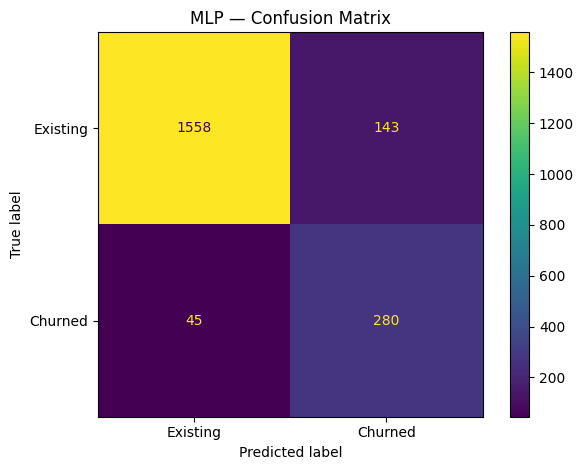

In [14]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=["Existing", "Churned"]).plot()
plt.title("MLP — Confusion Matrix")
plt.tight_layout()
plt.show()


## 3. Tree-based models (unscaled features)

### Decision tree

Hyperparameters are chosen with `GridSearchCV` (5-fold CV, F1 scoring). The best estimator is used for test-set evaluation, visualization, and importances.
We tune:
- **max_depth**: Controls how deep the tree grows (prevents overfitting)
- **min_samples_split**: Minimum number of samples required to split a node


In [15]:
params = {
    "max_depth": [3, 4, 5, 6], #different tree depths to try
    "min_samples_split": [2, 5, 10]  #different minimum samples needed
}

# Grid search with cross-validation to find best parameters
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    params,
    cv=5,
    scoring="f1"  #optimize fro F1 as it is important for churn
)

# train models for all parameter combinations
grid.fit(X_train, y_train)

#store the best performing model and output it
best_dt = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 6, 'min_samples_split': 2}


### Decision Tree Model Evaluation

Evaluate the best decision tree model's performance on the test set.  

Compute:
- **Accuracy**: Overall correctness  
- **Precision**: How many predicted churn cases are actually churn  
- **Recall**: How many actual churn cases are correctly identified  
- **F1 Score**: Balance between precision and recall 

In [16]:
# Train the best model on training data
dt_model = best_dt
dt_model.fit(X_train, y_train)

# Genreate predicitons on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate model performance using classification methods
dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt)
}

# Display the results
pd.DataFrame(dt_metrics, index=["Decision Tree"]).T

,Decision Tree
Accuracy,0.904245
Precision,0.646532
Recall,0.889231
F1 Score,0.748705


### Decision Tree Confusion Matrix

The confusion matrix visualizes the performance of the Decision Tree model by showing the number of correct and incorrect predictions

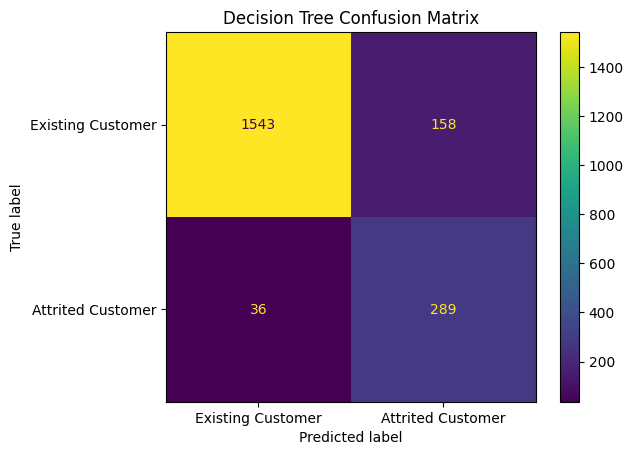

In [17]:
# Compute confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Existing Customer", "Attrited Customer"]
)

disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()


### Decision Tree Visualization

The decision tree visualization shows how the model makes predictions based on different features

Each split represents a decision rule, showing how customer characteristics influence whether a customer is likely to churn or stay

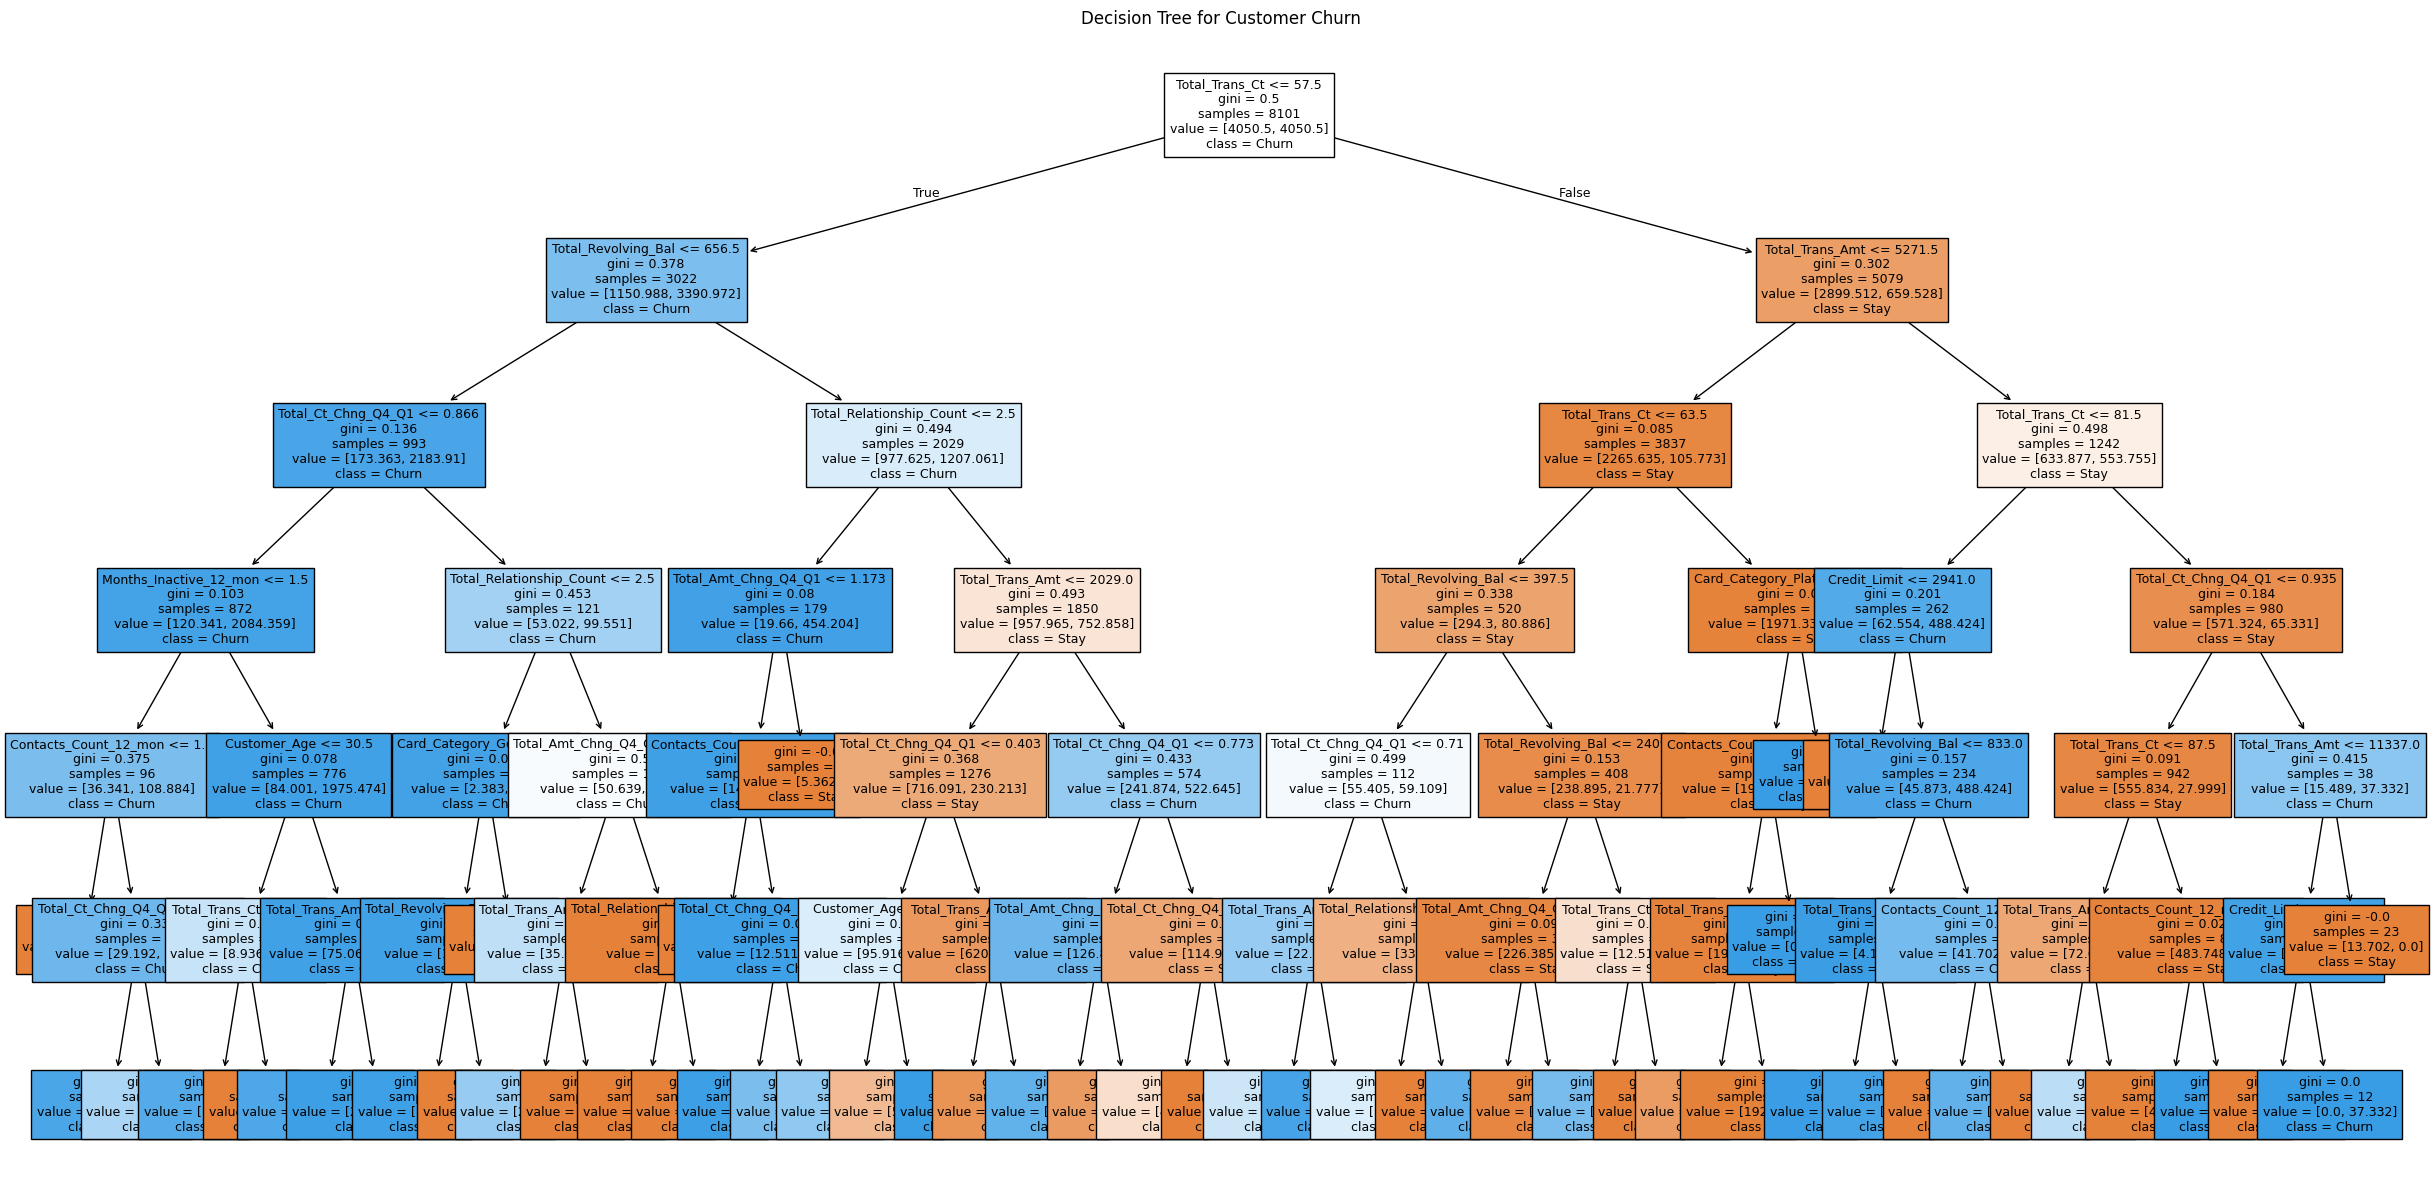

In [18]:
# Need a large figure so the tree structure can be visible
plt.figure(figsize=(30, 15))

# Plot the trained decision tree
plot_tree(
    dt_model, #trained decision tree model
    feature_names=X_train.columns, #name of input features at each split
    class_names=["Stay", "Churn"], # Labels for the target classes
    filled=True,
    fontsize=9
)
#display the decision tree
plt.title("Decision Tree for Customer Churn")
plt.show()


### Decision Tree Feature Importance

Feature importance measures how much each variable contributes to the model’s predictions.  
The higher the importance, the more influence it has on whether a customer will churn

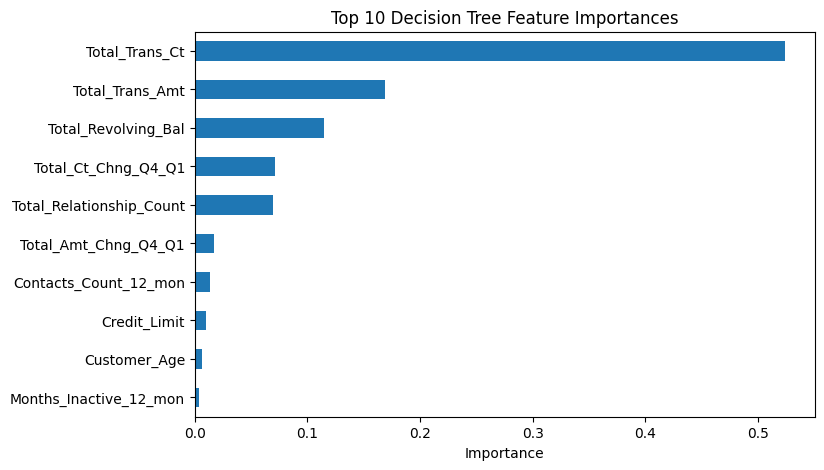

Total_Trans_Ct              0.524448
Total_Trans_Amt             0.168689
Total_Revolving_Bal         0.114902
Total_Ct_Chng_Q4_Q1         0.070947
Total_Relationship_Count    0.068994
Total_Amt_Chng_Q4_Q1        0.016735
Contacts_Count_12_mon       0.013041
Credit_Limit                0.009576
Customer_Age                0.006670
Months_Inactive_12_mon      0.003743
dtype: float64

In [19]:
# Extract feature importance scores from the trained Decision Tree model
dt_importance = pd.Series(dt_model.feature_importances_, index=X.columns)
# Sort features from most to least important and select the top 10
dt_top = dt_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
dt_top.sort_values().plot(kind="barh") # Plot features so the most important appear at the top
plt.title("Top 10 Decision Tree Feature Importances")

# Display the plot
plt.xlabel("Importance")
plt.show()

# Output the top features and their importance
dt_top


### Random Forest Model

The Random Forest model is a method that combines multiple decision trees to improve prediction accuracy, reduce overfitting, and capture complex patterns which will lead to more accurate churn predictions


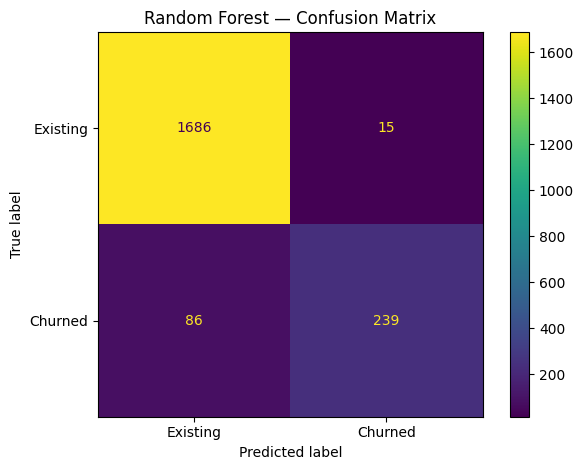

In [20]:
# Initialize random forest model
# random_state ensures reporoducability and "balanced" adjusts for class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")

# Train the model on the training dataset
rf_model.fit(X_train, y_train)

#generate predictions on the test dataset
y_pred_rf = rf_model.predict(X_test)


# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Existing", "Churned"]).plot()
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


### Model Performance Comparison

To evaluate model performance, compute classification metrics for the Random Forest model

Then compare these results with the Decision Tree model to determine which approach provides better overall performance and a more reliable prediction of customer churn.

In [21]:
# Store evaluation metrics for the Random Forest model
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

# Create a comparison table between Decision Tree and Random Forest
comparison_df = pd.DataFrame({
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
})

# Display comparison
comparison_df

,Decision Tree,Random Forest
Accuracy,0.904245,0.950148
Precision,0.646532,0.940945
Recall,0.889231,0.735385
F1 Score,0.748705,0.825561


### Random Forest Feature Importance

Feature importance in the Random Forest model indicates how much each variable contributes to predicting customer churn.


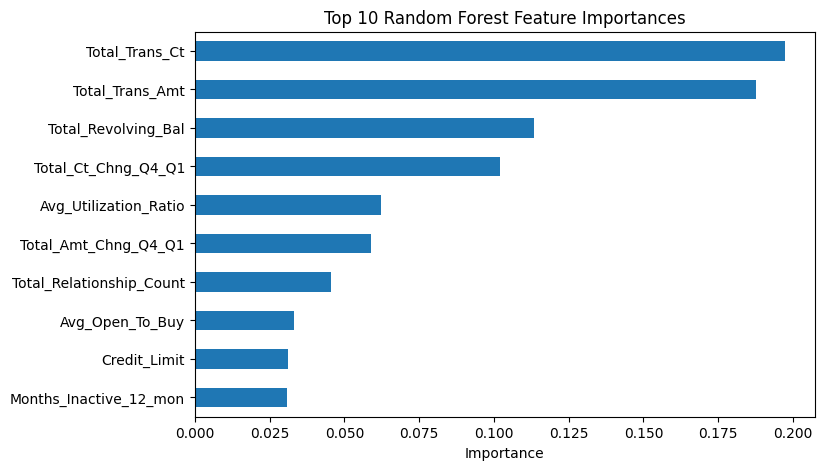

Total_Trans_Ct              0.197449
Total_Trans_Amt             0.187686
Total_Revolving_Bal         0.113328
Total_Ct_Chng_Q4_Q1         0.101884
Avg_Utilization_Ratio       0.062267
Total_Amt_Chng_Q4_Q1        0.058790
Total_Relationship_Count    0.045627
Avg_Open_To_Buy             0.033210
Credit_Limit                0.031036
Months_Inactive_12_mon      0.030772
dtype: float64

In [22]:
#Get feature importance scores
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
# Select top 10 features
rf_top = rf_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))

# Plot top features
rf_top.sort_values().plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

# Dsiplay values
rf_top

## 4. KNN (scaled features)

KNN uses distances between customers, so we train and evaluate on **scaled** features (`StandardScaler` above).

**Choosing $k$:** We do not pick a fixed $k$ without evidence. For each $k \in \{1,\ldots,20\}$, we run **5-fold cross-validation on the training set only**, record the **mean validation accuracy**, and choose the $k$ with the best mean score. We then **refit on the full training set** with that $k$ and evaluate on the **held-out test** set. The next cell plots mean CV accuracy vs. $k$ so the choice is visible.

*Note:* Accuracy can overweight the majority (non-churn) class. If you care more about catching churn, repeat the search with `scoring="f1"` instead.

We use `weights="distance"` so closer neighbors influence the vote more.

Best k (max mean 5-fold CV accuracy on training): k = 10
Mean CV accuracy at best k: 0.8767


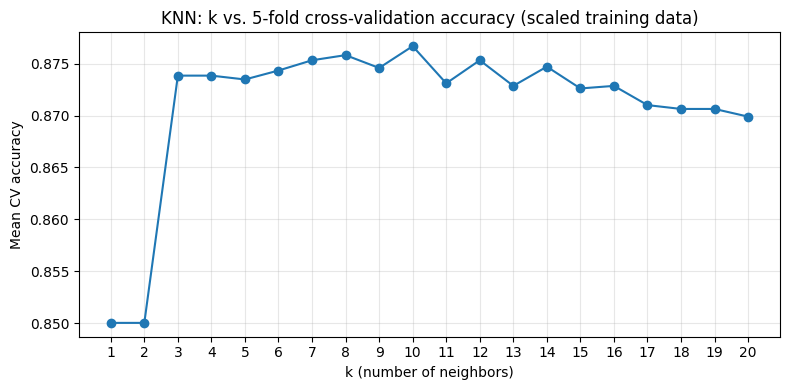

,KNN (k=10)
Accuracy,0.872655
Precision,0.831683
Recall,0.258462
F1 Score,0.394366


In [23]:
k_range = list(range(1, 21))
cv_mean_acc = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k, weights="distance")
    scores = cross_val_score(
        knn_cv, X_train_scaled, y_train, cv=5, scoring="accuracy"
    )
    cv_mean_acc.append(scores.mean())

best_k = k_range[int(np.argmax(cv_mean_acc))]
print(f"Best k (max mean 5-fold CV accuracy on training): k = {best_k}")
print(f"Mean CV accuracy at best k: {max(cv_mean_acc):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_mean_acc, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: k vs. 5-fold cross-validation accuracy (scaled training data)")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, weights="distance")
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
}
pd.DataFrame(knn_metrics, index=[f"KNN (k={best_k})"]).T


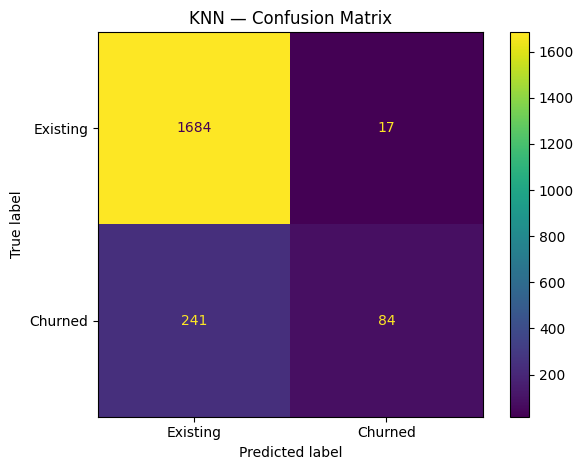

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Existing", "Churned"]).plot()
plt.title("KNN — Confusion Matrix")
plt.tight_layout()
plt.show()


## Test-set metric comparison

In [25]:
summary = pd.DataFrame(
    [log_metrics, mlp_metrics, dt_metrics, rf_metrics, knn_metrics],
    index=[
        "Logistic Regression",
        "MLP",
        "Decision Tree",
        "Random Forest",
        f"KNN (k={best_k})",
    ],
)
summary.round(4)


,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.8549,0.5309,0.8185,0.6441,0.9207
MLP,0.9072,0.6619,0.8615,0.7487,NaN
Decision Tree,0.9042,0.6465,0.8892,0.7487,NaN
Random Forest,0.9501,0.9409,0.7354,0.8256,NaN
KNN (k=10),0.8727,0.8317,0.2585,0.3944,NaN


## Interpretation and takeaways

### Reading the test-set summary

Use the comparison table together with the confusion matrices. **Accuracy** can look high even when churn (the minority class) is predicted poorly, so compare **precision, recall, and F1** for the churn class as well. Business priorities should determine whether recall (catching churners) or precision (limiting false alarms) matters more.

**AUC in the table:** Only **logistic regression** includes **AUC** in the combined summary, because we pass its positive-class **predicted probabilities** to `roc_auc_score`. Other models could report AUC the same way; leaving them blank avoids implying a number we did not add to their metric dicts.

**KNN:** Neighbor count *k* was chosen by **5-fold CV mean accuracy on the training set**, not by F1 or recall on churn. That can yield strong overall accuracy but weaker **recall / F1 on the minority class** if “similar neighbors” mostly vote *existing customer*—check KNN’s confusion matrix alongside the table.

### What drives churn?

- **Logistic regression:** Coefficient magnitudes show which engineered features move the **log-odds** of churn; results are **associative**, not causal.
- **Decision tree:** Importances and the tree diagram express **rule-based** patterns (e.g. engagement or balance splits). Agreement with large logistic coefficients strengthens a consistent narrative on risk drivers.
- **Random forest:** Ensemble importances **average** contributions across trees; they are typically smoother than a single tree and highlight robust predictors, with less sensitivity to one fragile split.

### Which model for which question?

| Need | Model to emphasize |
|------|---------------------|
| Transparent linear effects | **Logistic regression** |
| Nonlinear fit, harder to explain per feature | **MLP** |
| Explicit **if–then** paths | **Decision tree** |
| Stable tree-based accuracy, aggregated drivers | **Random forest** |
| Similarity to labeled neighbors | **KNN** (*k* from CV) |

### Limitations and extensions

- Metrics reflect **one** stratified split (`random_state=42`); multi-fold evaluation across all models would tighten comparisons.
- Retention decisions should still combine model output with **policy and domain** constraints.
- Extensions: probability **calibration**, cost-sensitive thresholds, or **SHAP** values for richer explanations beyond importances.
